In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport, ROCAUC

# **LOAD DATA TO DATAFRAME**

In [2]:
# Load semua dataset
df_train = pd.read_csv('application_train.csv')
df_test = pd.read_csv('application_test.csv')
bureau = pd.read_csv('bureau.csv')
prev_app = pd.read_csv('previous_application.csv')

# Buat tabel summary shape
dataset_summary = pd.DataFrame({
    'Dataset': ['Application Train', 'Application Test', 'Bureau', 'Previous Application'],
    'Rows': [df_train.shape[0], df_test.shape[0], bureau.shape[0], prev_app.shape[0]],
    'Columns': [df_train.shape[1], df_test.shape[1], bureau.shape[1], prev_app.shape[1]]
})

dataset_summary

,Dataset,Rows,Columns
0,Application Train,307511,122
1,Application Test,48744,121
2,Bureau,1716428,17
3,Previous Application,1670214,37


In [3]:
# Agregasi Bureau (riwayat kredit di bank lain)
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT': ['mean', 'min'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_SUM_DEBT': 'sum'
}).reset_index()

bureau_agg.columns = ['SK_ID_CURR', 'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MIN',
                      'BUREAU_MAX_OVERDUE', 'BUREAU_AVG_OVERDUE', 
                      'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_DEBT']

# Hitung jumlah kredit di bureau
bureau_count = bureau.groupby('SK_ID_CURR').size().reset_index(name='BUREAU_COUNT')
bureau_agg = bureau_agg.merge(bureau_count, on='SK_ID_CURR', how='left')

print(f"Bureau features shape: {bureau_agg.shape}")

Bureau features shape: (305811, 8)


In [4]:
# Agregasi Previous Application (riwayat aplikasi sebelumnya)
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT': ['sum', 'mean', 'max'],
    'AMT_ANNUITY': 'mean',
    'DAYS_DECISION': 'mean'
}).reset_index()

prev_agg.columns = ['SK_ID_CURR', 'PREV_CREDIT_SUM', 'PREV_CREDIT_MEAN', 'PREV_CREDIT_MAX',
                    'PREV_ANNUITY_MEAN', 'PREV_DAYS_DECISION_MEAN']

# Hitung jumlah aplikasi sebelumnya
prev_count = prev_app.groupby('SK_ID_CURR').size().reset_index(name='PREV_APP_COUNT')
prev_agg = prev_agg.merge(prev_count, on='SK_ID_CURR', how='left')

# Hitung approved vs rejected
prev_approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size().reset_index(name='PREV_APPROVED_COUNT')
prev_agg = prev_agg.merge(prev_approved, on='SK_ID_CURR', how='left').fillna(0)

print(f"Previous App features shape: {prev_agg.shape}")

Previous App features shape: (338857, 8)


In [5]:
# Gabungkan features ke train dan test
df_train = df_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
df_train = df_train.merge(prev_agg, on='SK_ID_CURR', how='left')

df_test = df_test.merge(bureau_agg, on='SK_ID_CURR', how='left')
df_test = df_test.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Train shape setelah merge: {df_train.shape}")
print(f"Test shape setelah merge: {df_test.shape}")

# Gunakan df_train untuk analisis (ganti df_HCI)
df_HCI = df_train.copy()
print(f"\ndf_HCI shape: {df_HCI.shape}")

Train shape setelah merge: (307511, 136)
Test shape setelah merge: (48744, 135)

df_HCI shape: (307511, 136)

df_HCI shape: (307511, 136)


In [6]:
# Data Shape (rows, columns)
print("Shape of the dataset:")
print(df_HCI.shape)
print(f'The dataset has {df_HCI.shape[0]} rows and {df_HCI.shape[1]} columns.')

Shape of the dataset:
(307511, 136)
The dataset has 307511 rows and 136 columns.


In [7]:
# Data Info
print("\nInfo of the dataset:")
df_HCI.info()


Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 136 entries, SK_ID_CURR to PREV_APPROVED_COUNT
dtypes: float64(79), int64(41), object(16)
memory usage: 319.1+ MB


In [8]:
# Data Description
print("\nDescription of the dataset:")
df_HCI.describe(include=['int64', 'float64']).T


Description of the dataset:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.50,278202.0000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.0,0.00,0.0000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.00,0.0000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.00,147150.0000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.00,513531.0000,808650.000000,4.050000e+06
...,...,...,...,...,...,...,...,...
PREV_CREDIT_MAX,291057.0,413865.566542,457538.382666,0.0,104431.50,225000.0000,547344.000000,4.509688e+06
PREV_ANNUITY_MEAN,291057.0,14511.232577,10015.406501,0.0,7818.48,11970.5175,18319.583571,3.004254e+05
PREV_DAYS_DECISION_MEAN,291057.0,-919.574157,577.765937,-2922.0,-1247.00,-789.0000,-466.800000,-2.000000e+00
PREV_APP_COUNT,291057.0,4.857128,4.147042,1.0,2.00,4.0000,6.000000,7.300000e+01


In [9]:
# Data Description (include object)
print("\nDescription of the dataset (include object):")
df_HCI.describe(include='object').T


Description of the dataset (include object):


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


# **EXPLORATORY DATA ANALYSIS**

In [10]:
# Check Target Distribution
print("\nTarget Distribution in the dataset:")
if 'TARGET' in df_HCI.columns:
    print("\nTarget distribution (TARGET):")
    print(df_HCI['TARGET'].value_counts(normalize=True).map("{:.2%}".format))


Target Distribution in the dataset:

Target distribution (TARGET):
TARGET
0    91.93%
1     8.07%
Name: proportion, dtype: object


0 = Peminjam lancar 

1 = Peminjam berpotensi mengalami kesulitan bayar

C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\3429167992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_HCI, x='TARGET', palette=['green', 'red'])


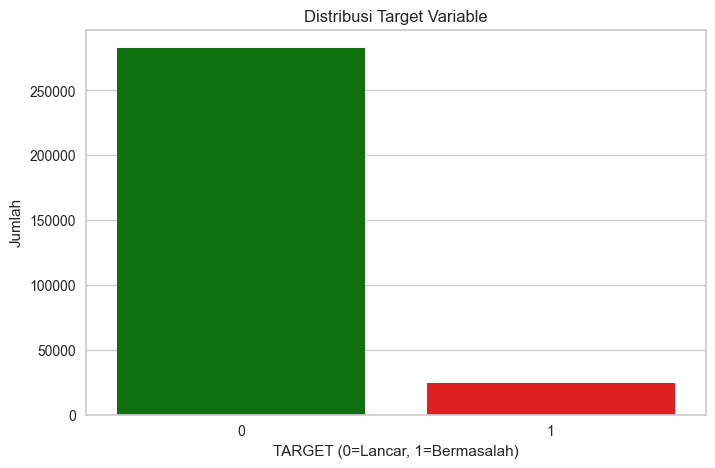

In [11]:
# Visualisasi Target Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_HCI, x='TARGET', palette=['green', 'red'])
plt.title('Distribusi Target Variable')
plt.xlabel('TARGET (0=Lancar, 1=Bermasalah)')
plt.ylabel('Jumlah')
plt.show()

## **1. ANALISIS UNIVARIAT**
Analisis distribusi masing-masing variabel

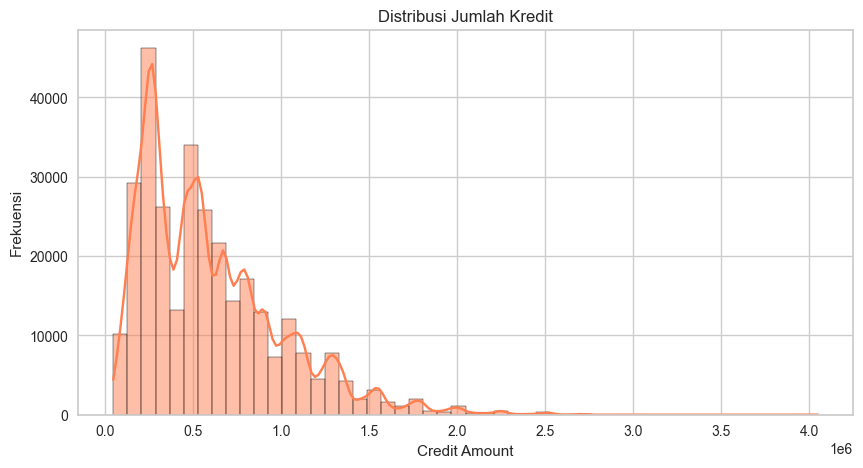

In [12]:
# Distribusi Credit Amount
plt.figure(figsize=(10, 5))
sns.histplot(df_HCI['AMT_CREDIT'], bins=50, color='coral', kde=True)
plt.title('Distribusi Jumlah Kredit')
plt.xlabel('Credit Amount')
plt.ylabel('Frekuensi')
plt.show()

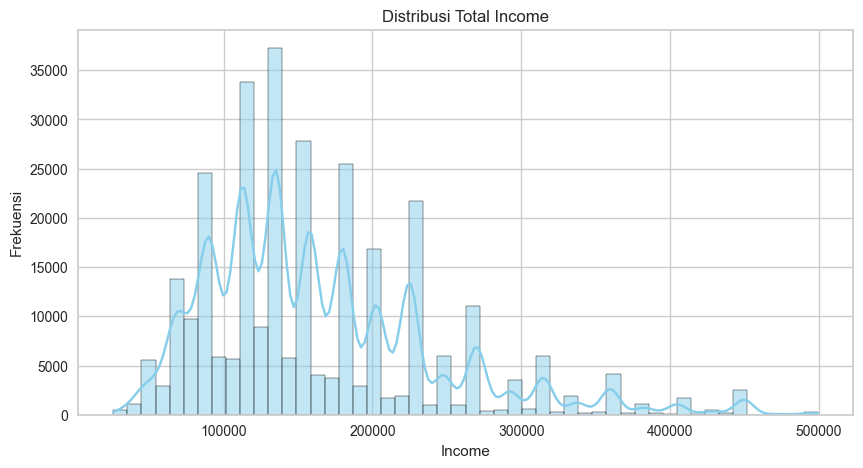

In [13]:
# Distribusi Income
plt.figure(figsize=(10, 5))
sns.histplot(df_HCI[df_HCI['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL'], 
             bins=50, color='skyblue', kde=True)
plt.title('Distribusi Total Income')
plt.xlabel('Income')
plt.ylabel('Frekuensi')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\613614148.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_HCI, x='CODE_GENDER', palette=['blue', 'pink'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\613614148.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_HCI, x='CODE_GENDER', palette=['blue', 'pink'])


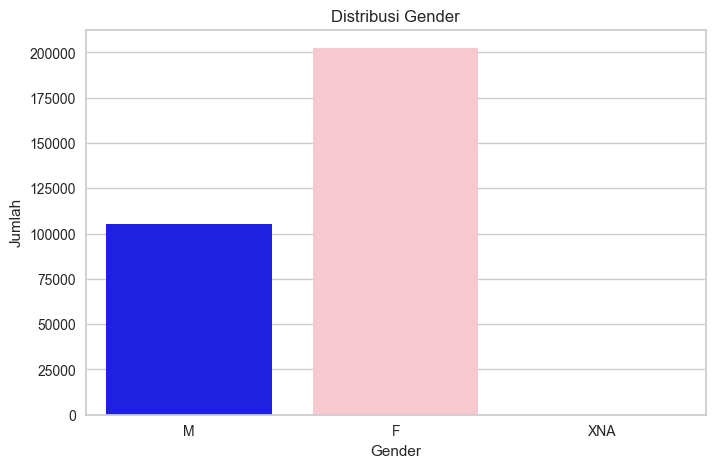

In [14]:
# Distribusi Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df_HCI, x='CODE_GENDER', palette=['blue', 'pink'])
plt.title('Distribusi Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.show()

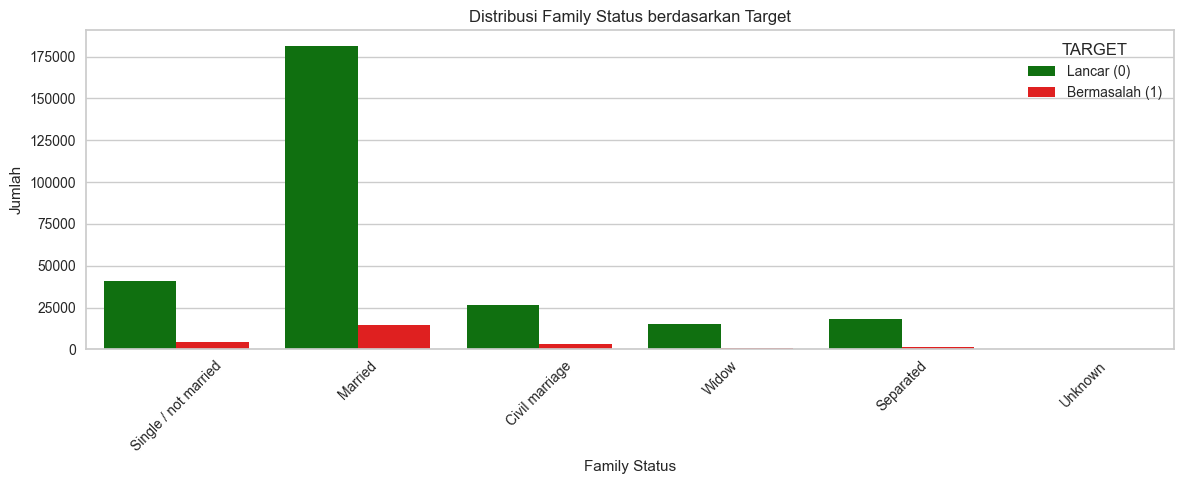

In [15]:
# Hubungan Family Status dengan Target
plt.figure(figsize=(12, 5))
sns.countplot(data=df_HCI, x='NAME_FAMILY_STATUS', hue='TARGET', palette=['green', 'red'])
plt.title('Distribusi Family Status berdasarkan Target')
plt.xlabel('Family Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='TARGET', labels=['Lancar (0)', 'Bermasalah (1)'])
plt.tight_layout()
plt.show()

## **2. ANALISIS BIVARIAT**
Analisis hubungan antara variabel dengan Target

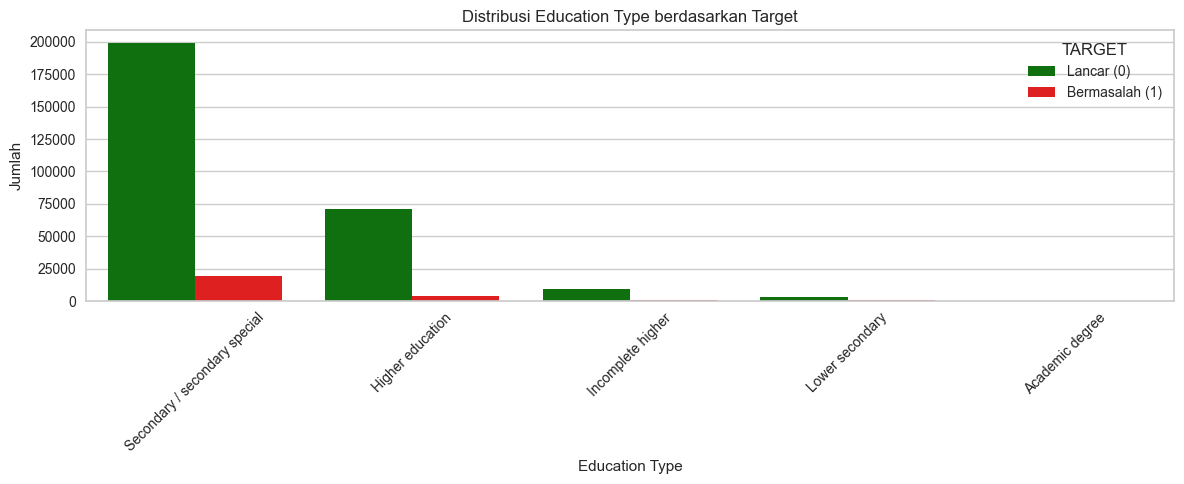

In [16]:
# Hubungan Education Type dengan Target
plt.figure(figsize=(12, 5))
sns.countplot(data=df_HCI, x='NAME_EDUCATION_TYPE', hue='TARGET', palette=['green', 'red'])
plt.title('Distribusi Education Type berdasarkan Target')
plt.xlabel('Education Type')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='TARGET', labels=['Lancar (0)', 'Bermasalah (1)'])
plt.tight_layout()
plt.show()

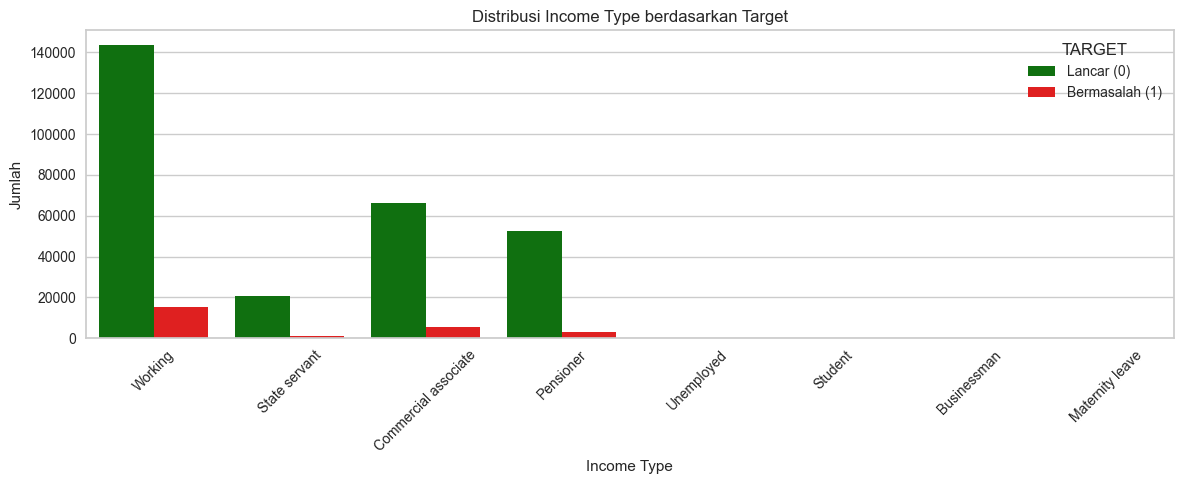

In [17]:
# Hubungan Income Type dengan Target
plt.figure(figsize=(12, 5))
sns.countplot(data=df_HCI, x='NAME_INCOME_TYPE', hue='TARGET', palette=['green', 'red'])
plt.title('Distribusi Income Type berdasarkan Target')
plt.xlabel('Income Type')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='TARGET', labels=['Lancar (0)', 'Bermasalah (1)'])
plt.tight_layout()
plt.show()

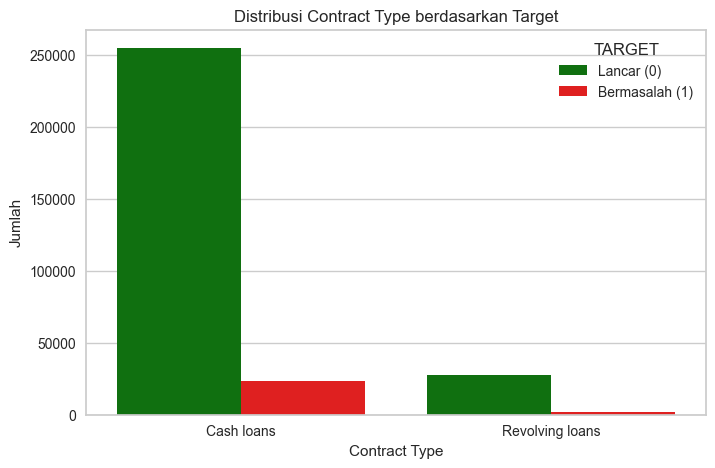

In [18]:
# Hubungan Contract Type dengan Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df_HCI, x='NAME_CONTRACT_TYPE', hue='TARGET', palette=['green', 'red'])
plt.title('Distribusi Contract Type berdasarkan Target')
plt.xlabel('Contract Type')
plt.ylabel('Jumlah')
plt.legend(title='TARGET', labels=['Lancar (0)', 'Bermasalah (1)'])
plt.show()

## **3. ANALISIS MULTIVARIAT**
Analisis korelasi antar variabel numerik

In [19]:
# Korelasi fitur numerik dengan Target
numeric_cols = df_HCI.select_dtypes(include=[np.number]).columns
correlation = df_HCI[numeric_cols].corr()['TARGET'].sort_values(ascending=False)
print("Top 10 Korelasi dengan TARGET:")
print(correlation.head(10))

Top 10 Korelasi dengan TARGET:
TARGET                         1.000000
BUREAU_DAYS_CREDIT_MEAN        0.089729
DAYS_BIRTH                     0.078239
BUREAU_DAYS_CREDIT_MIN         0.075248
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
PREV_DAYS_DECISION_MEAN        0.046864
Name: TARGET, dtype: float64


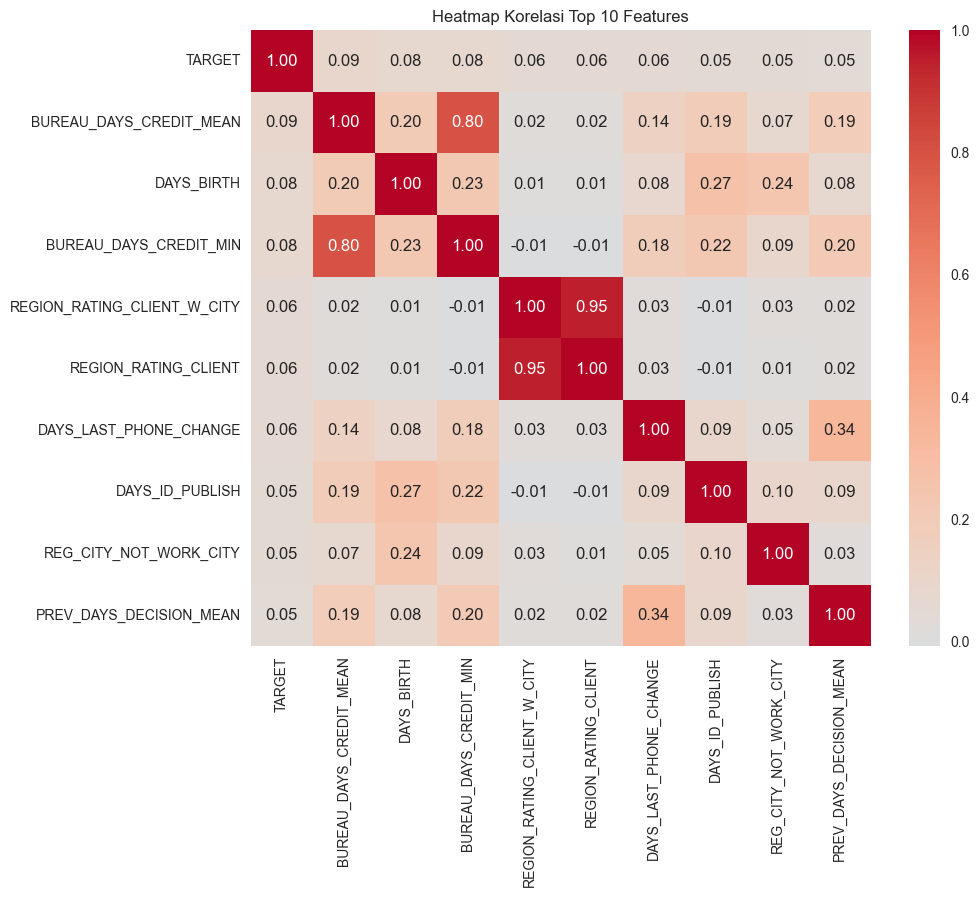

In [20]:
# Heatmap Korelasi (Top Features)
top_corr = correlation.head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_HCI[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Top 10 Features')
plt.show()

In [21]:
# Korelasi variabel kategori dengan Target (Chi-Square Test)
from scipy.stats import chi2_contingency

cat_cols = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

cat_corr = {}
for col in cat_cols:
    crosstab = pd.crosstab(df_HCI[col], df_HCI['TARGET'])
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    cat_corr[col] = cramers_v

cat_corr_df = pd.DataFrame(list(cat_corr.items()), columns=['Variable', 'Cramers_V'])
cat_corr_df = cat_corr_df.sort_values('Cramers_V', ascending=False)
print("\nKorelasi Variabel Kategori dengan TARGET:")
print(cat_corr_df)


Korelasi Variabel Kategori dengan TARGET:
              Variable  Cramers_V
2     NAME_INCOME_TYPE   0.063845
3  NAME_EDUCATION_TYPE   0.057571
0          CODE_GENDER   0.054721
4   NAME_FAMILY_STATUS   0.040512
5    NAME_HOUSING_TYPE   0.036981
1   NAME_CONTRACT_TYPE   0.030876


C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\3693112287.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_corr_df, x='Cramers_V', y='Variable', palette='viridis')


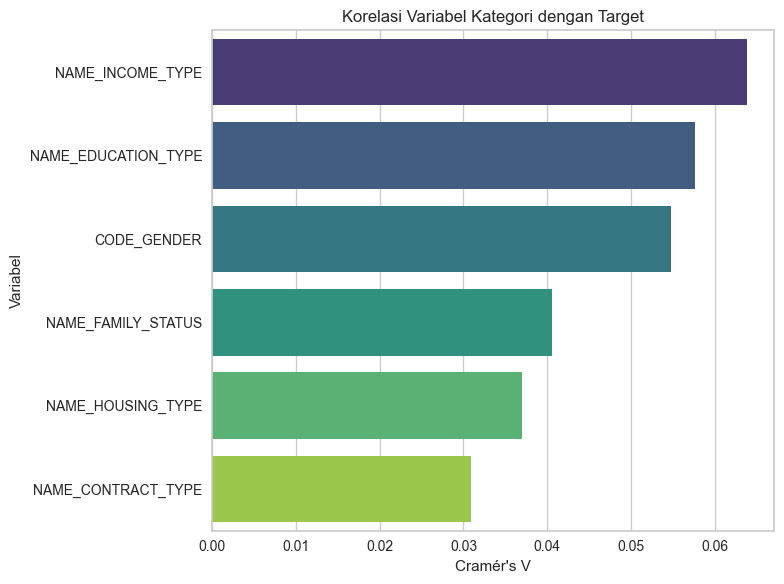

In [22]:
# Visualisasi Korelasi Kategori dengan Target
plt.figure(figsize=(8, 6))
sns.barplot(data=cat_corr_df, x='Cramers_V', y='Variable', palette='viridis')
plt.title("Korelasi Variabel Kategori dengan Target")
plt.xlabel("Cramér's V")
plt.ylabel('Variabel')
plt.tight_layout()
plt.show()

# **DATA PREPROCESSING**

## **HANDLING MISSING VALUES**

In [23]:
# Check Missing Values
missing_data = pd.DataFrame({
    'Kolom': df_HCI.columns,
    'Total_Missing': df_HCI.isnull().sum().values,
    'Persentase (%)': (df_HCI.isnull().sum().values / len(df_HCI) * 100).round(2)
})

# Filter hanya kolom yang memiliki missing values
missing_data = missing_data[missing_data['Total_Missing'] > 0].sort_values('Total_Missing', ascending=False)
print(f"Total kolom dengan missing values: {len(missing_data)}")
print("\n" + "="*60)
missing_data.head(20)

Total kolom dengan missing values: 81



,Kolom,Total_Missing,Persentase (%)
48,COMMONAREA_AVG,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
62,COMMONAREA_MODE,214865,69.87
56,NONLIVINGAPARTMENTS_AVG,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
86,FONDKAPREMONT_MODE,210295,68.39
82,LIVINGAPARTMENTS_MEDI,210199,68.35
68,LIVINGAPARTMENTS_MODE,210199,68.35
54,LIVINGAPARTMENTS_AVG,210199,68.35


In [24]:
# Hapus kolom dengan missing values > 40%
threshold = 40
cols_to_drop = missing_data[missing_data['Persentase (%)'] > threshold]['Kolom'].tolist()

print(f"Kolom yang dihapus (missing > {threshold}%): {len(cols_to_drop)}")
print(cols_to_drop)

# Drop kolom
df_HCI = df_HCI.drop(columns=cols_to_drop)
print(f"\nShape setelah drop kolom: {df_HCI.shape}")

Kolom yang dihapus (missing > 40%): 49
['COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'WALLSMATERIAL_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'HOUSETYPE_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG',

In [25]:
# Drop kolom yang tidak relevan (ID dan FLAG)
cols_to_remove = [col for col in df_HCI.columns if 'SK_ID' in col or 'FLAG_DOCUMENT' in col]
print(f"Kolom yang dihapus (ID & FLAG): {len(cols_to_remove)}")
print(cols_to_remove)

df_HCI = df_HCI.drop(columns=cols_to_remove)
print(f"\nShape setelah drop: {df_HCI.shape}")

Kolom yang dihapus (ID & FLAG): 21
['SK_ID_CURR', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']

Shape setelah drop: (307511, 66)


In [26]:
# Pisahkan kolom numerik dan kategorikal
num_cols = df_HCI.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_HCI.select_dtypes(include=['object']).columns.tolist()

# Remove TARGET dari num_cols jika ada
if 'TARGET' in num_cols:
    num_cols.remove('TARGET')

print(f"Kolom numerik: {len(num_cols)}")
print(f"Kolom kategorikal: {len(cat_cols)}")

Kolom numerik: 53
Kolom kategorikal: 12


In [27]:
# Imputasi Numerik dengan median
imputer_num = SimpleImputer(strategy='median')
df_HCI[num_cols] = imputer_num.fit_transform(df_HCI[num_cols])

# Imputasi Kategorikal dengan modus
imputer_cat = SimpleImputer(strategy='most_frequent')
df_HCI[cat_cols] = imputer_cat.fit_transform(df_HCI[cat_cols])

print("Imputasi selesai!")
print(f"Total missing values sekarang: {df_HCI.isnull().sum().sum()}")

Imputasi selesai!
Total missing values sekarang: 0
Total missing values sekarang: 0


## **HANDLING DUPLICATE VALUES**

In [28]:
df_HCI.duplicated().sum()

np.int64(0)

## **FEATURE ENGINEERING**
Konversi kolom DAYS menjadi lebih mudah dipahami

In [29]:
# Konversi DAYS menjadi tahun
df_HCI['AGE_YEARS'] = (-df_HCI['DAYS_BIRTH'] / 365).astype(int)
df_HCI['YEARS_EMPLOYED'] = df_HCI['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x<0 else 0)

# Buat rasio fitur
df_HCI['CREDIT_INCOME_RATIO'] = df_HCI['AMT_CREDIT'] / df_HCI['AMT_INCOME_TOTAL']
df_HCI['ANNUITY_INCOME_RATIO'] = df_HCI['AMT_ANNUITY'] / df_HCI['AMT_INCOME_TOTAL']

print("Feature Engineering selesai!")
print(f"Shape: {df_HCI.shape}")

Feature Engineering selesai!
Shape: (307511, 70)


## **ENCODING CATEGORICAL VARIABLES**

In [30]:
# Encoding kategorikal
le = LabelEncoder()
for col in cat_cols:
    df_HCI[col] = le.fit_transform(df_HCI[col].astype(str))

print(f"Encoding selesai! {len(cat_cols)} kolom di-encode.")

Encoding selesai! 12 kolom di-encode.


# **MODEL TRAINING**

## **FEATURE SCALING**
Scaling untuk kolom yang belum dinormalisasi (EXT_SOURCE sudah normalized)

In [31]:
# Pisahkan X dan y
X = df_HCI.drop('TARGET', axis=1)
y = df_HCI['TARGET']

# Kolom yang sudah normalized
normalized_cols = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE']
cols_to_scale = [col for col in num_cols if col not in normalized_cols and col in X.columns]

# Scaling
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print(f"Scaling selesai! {len(cols_to_scale)} kolom di-scale.")
print(f"Shape X: {X.shape}, y: {y.shape}")

Scaling selesai! 50 kolom di-scale.
Shape X: (307511, 69), y: (307511,)


## **TRAIN-TEST SPLIT**

In [32]:
# Split data menjadi train dan validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"\nDistribusi y_train:")
print(y_train.value_counts(normalize=True))

X_train shape: (246008, 69)
X_val shape: (61503, 69)

Distribusi y_train:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


## **HANDLING IMBALANCED DATA**

C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\3000077479.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=['green', 'red'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\3000077479.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette=['green', 'red'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\3000077479.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette=['green', 'red'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_

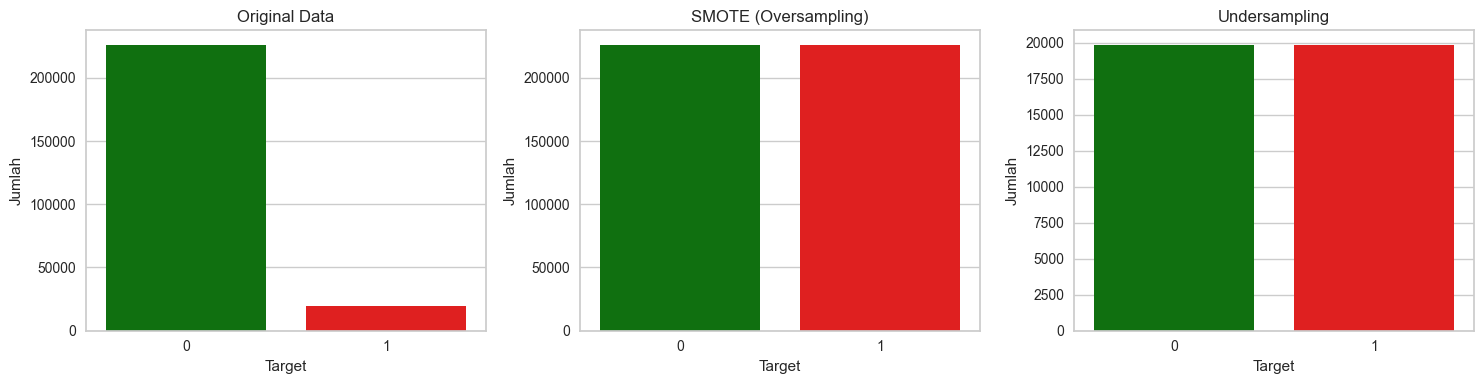

In [33]:
# 1. Oversampling dengan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Undersampling
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

# Visualisasi perbandingan distribusi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
sns.countplot(x=y_train, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Original Data')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Jumlah')

# SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('SMOTE (Oversampling)')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Jumlah')

# Undersampling
sns.countplot(x=y_train_under, ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Undersampling')
axes[2].set_xlabel('Target')
axes[2].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

## **MODEL 1: LOGISTIC REGRESSION (ORIGINAL DATA)**

In [34]:
# Train model
lr_original = LogisticRegression(random_state=42, max_iter=1000)
lr_original.fit(X_train, y_train)

# Prediksi
y_pred_original = lr_original.predict(X_val)

# Evaluasi
print("Logistic Regression (Original Data):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_original):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_original):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_original))

Logistic Regression (Original Data):
Accuracy: 0.9195
ROC-AUC: 0.5060

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



## **MODEL 2: LOGISTIC REGRESSION (SMOTE)**

In [35]:
# Train model dengan SMOTE
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)

# Prediksi
y_pred_smote = lr_smote.predict(X_val)

# Evaluasi
print("Logistic Regression (SMOTE):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_smote))

Logistic Regression (SMOTE):
Accuracy: 0.7609
ROC-AUC: 0.6112

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     56538
           1       0.15      0.43      0.23      4965

    accuracy                           0.76     61503
   macro avg       0.55      0.61      0.54     61503
weighted avg       0.88      0.76      0.81     61503



C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **MODEL 3: LOGISTIC REGRESSION (UNDERSAMPLING)**

In [36]:
# Train model dengan Undersampling
lr_under = LogisticRegression(random_state=42, max_iter=1000)
lr_under.fit(X_train_under, y_train_under)

# Prediksi
y_pred_under = lr_under.predict(X_val)

# Evaluasi
print("Logistic Regression (Undersampling):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_under):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_under):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_under))

Logistic Regression (Undersampling):
Accuracy: 0.6894
ROC-AUC: 0.6843

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **MODEL 5: RANDOM FOREST (UNDERSAMPLING)**

In [37]:
# Train model dengan Undersampling
rf_under = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_under.fit(X_train_under, y_train_under)

# Prediksi
y_pred_rf_under = rf_under.predict(X_val)

# Evaluasi
print("Random Forest (Undersampling):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_under):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_rf_under):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_under))

Random Forest (Undersampling):
Accuracy: 0.6901
ROC-AUC: 0.6772

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.66      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.69      0.76     61503



## **MODEL 6: RANDOM FOREST (SMOTE)**

In [38]:
# Train model dengan SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

# Prediksi
y_pred_rf_smote = rf_smote.predict(X_val)

# Evaluasi
print("Random Forest (SMOTE):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_rf_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_smote))

Random Forest (SMOTE):
Accuracy: 0.9155
ROC-AUC: 0.5087

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.25      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.59      0.51      0.50     61503
weighted avg       0.87      0.92      0.88     61503



## **MODEL 6: RANDOM FOREST (DATA ORIGINAL)**

In [39]:
# Train model
rf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)

# Prediksi
y_pred_rf_original = rf_original.predict(X_val)

# Evaluasi
print("Random Forest (Original Data):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_original):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_rf_original):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf_original))

Random Forest (Original Data):
Accuracy: 0.9193
ROC-AUC: 0.5009

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.64      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.78      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503



## **PERBANDINGAN MODEL**

In [40]:
# Buat tabel perbandingan semua model
comparison = pd.DataFrame({
    'Model': ['LR-Original', 'LR-SMOTE', 'LR-Undersampling', 
              'RF-Original', 'RF-SMOTE', 'RF-Undersampling'],
    'Accuracy': [
        accuracy_score(y_val, y_pred_original),
        accuracy_score(y_val, y_pred_smote),
        accuracy_score(y_val, y_pred_under),
        accuracy_score(y_val, y_pred_rf_original),
        accuracy_score(y_val, y_pred_rf_smote),
        accuracy_score(y_val, y_pred_rf_under)
    ],
    'ROC-AUC': [
        roc_auc_score(y_val, y_pred_original),
        roc_auc_score(y_val, y_pred_smote),
        roc_auc_score(y_val, y_pred_under),
        roc_auc_score(y_val, y_pred_rf_original),
        roc_auc_score(y_val, y_pred_rf_smote),
        roc_auc_score(y_val, y_pred_rf_under)
    ]
})

print("Perbandingan Semua Model:")
print(comparison)

Perbandingan Semua Model:
              Model  Accuracy   ROC-AUC
0       LR-Original  0.919467  0.505985
1          LR-SMOTE  0.760857  0.611247
2  LR-Undersampling  0.689381  0.684257
3       RF-Original  0.919337  0.500862
4          RF-SMOTE  0.915500  0.508696
5  RF-Undersampling  0.690129  0.677223


## **VISUALISASI PERFORMA MODEL (YELLOWBRICK)**

In [41]:
# Definisi semua model untuk visualisasi
models = [
    (lr_original, y_pred_original, 'LR-Original'),
    (lr_smote, y_pred_smote, 'LR-SMOTE'),
    (lr_under, y_pred_under, 'LR-Undersampling'),
    (rf_original, y_pred_rf_original, 'RF-Original'),
    (rf_smote, y_pred_rf_smote, 'RF-SMOTE'),
    (rf_under, y_pred_rf_under, 'RF-Undersampling')
]

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\ba

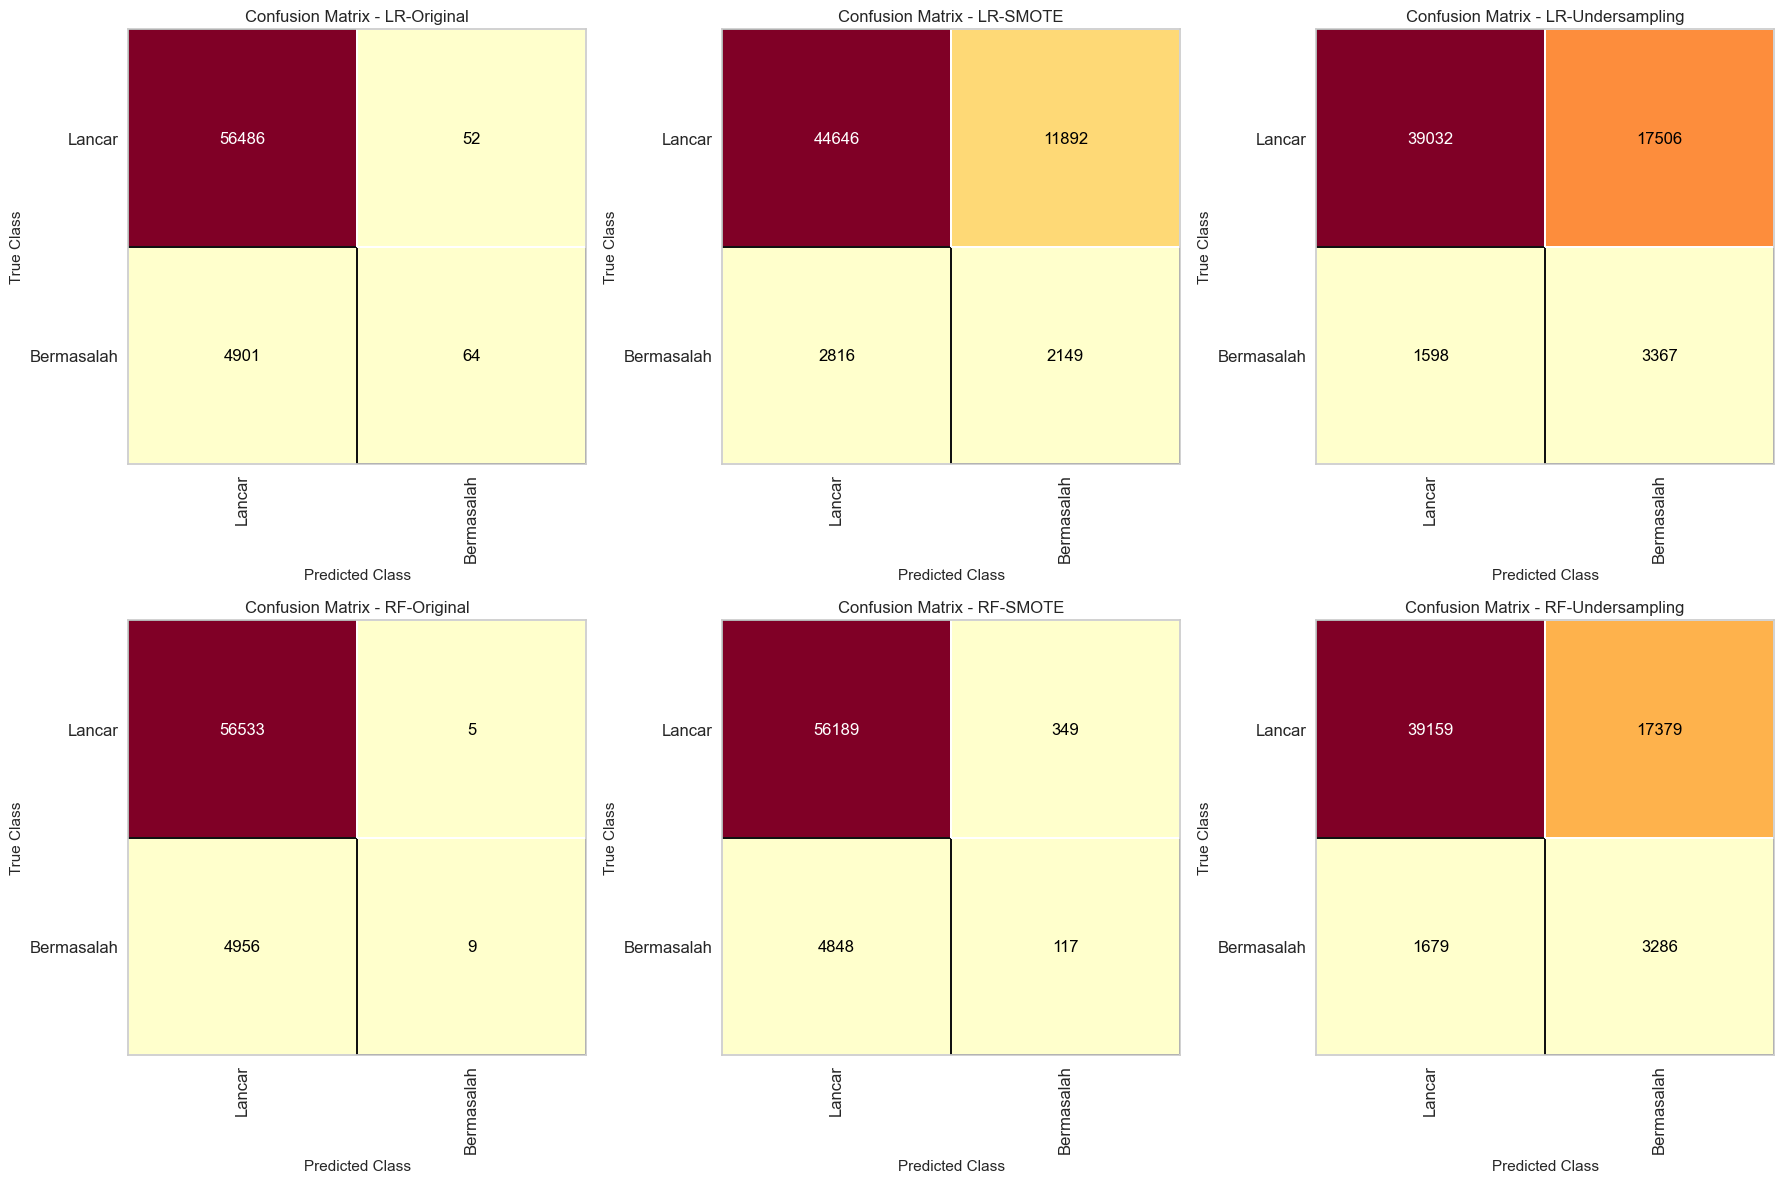

In [42]:
# Confusion Matrix untuk semua model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (model, y_pred, title) in enumerate(models):
    ax = axes[idx // 3, idx % 3]
    visualizer = ConfusionMatrix(model, ax=ax, classes=['Lancar', 'Bermasalah'])
    visualizer.score(X_val, y_val)
    visualizer.finalize()
    ax.set_title(f'Confusion Matrix - {title}')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\yellowbrick\classifier\ba

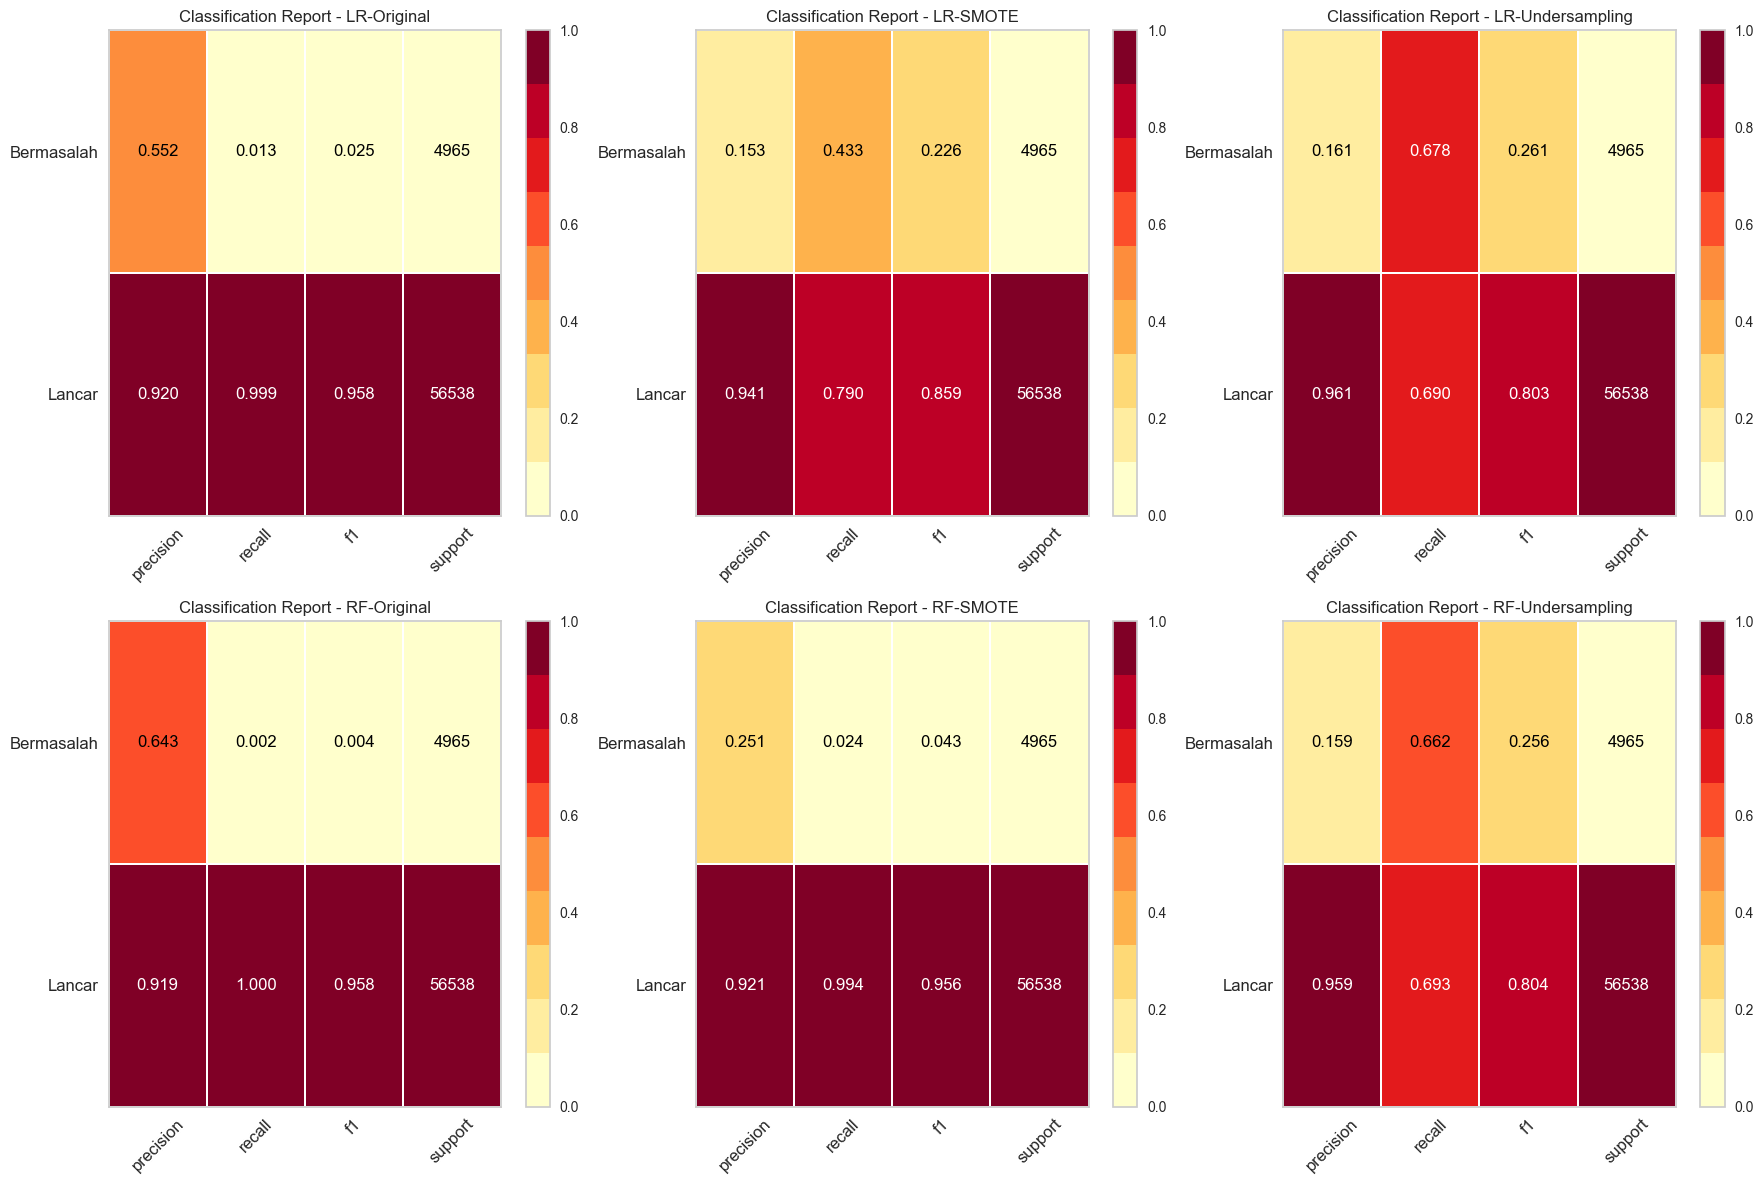

In [43]:
# Classification Report untuk semua model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (model, y_pred, title) in enumerate(models):
    ax = axes[idx // 3, idx % 3]
    visualizer = ClassificationReport(model, ax=ax, classes=['Lancar', 'Bermasalah'], support=True)
    visualizer.score(X_val, y_val)
    visualizer.finalize()
    ax.set_title(f'Classification Report - {title}')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\

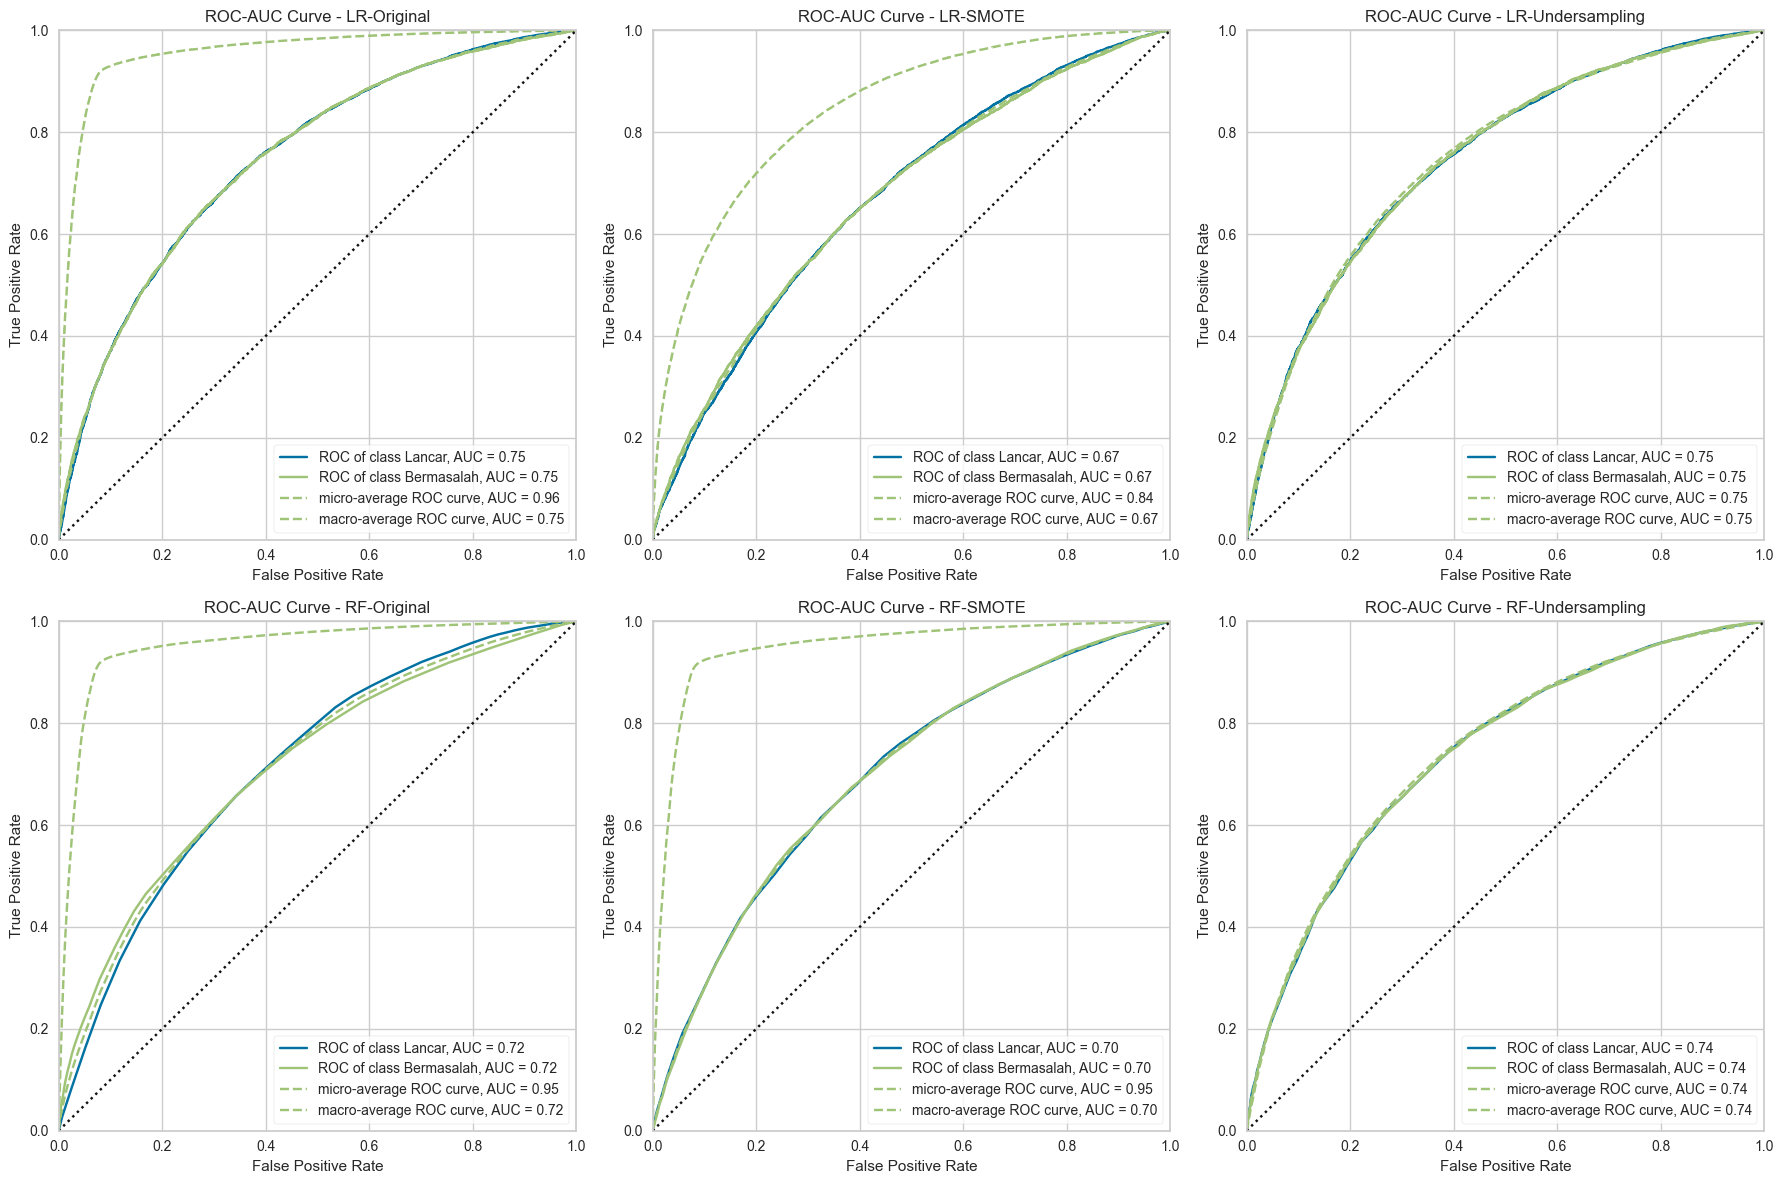

In [44]:
# ROC-AUC Curve untuk semua model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# List model dengan data training yang sesuai
models_roc = [
    (lr_original, X_train, y_train, 'LR-Original'),
    (lr_smote, X_train_smote, y_train_smote, 'LR-SMOTE'),
    (lr_under, X_train_under, y_train_under, 'LR-Undersampling'),
    (rf_original, X_train, y_train, 'RF-Original'),
    (rf_smote, X_train_smote, y_train_smote, 'RF-SMOTE'),
    (rf_under, X_train_under, y_train_under, 'RF-Undersampling')
]

for idx, (model, X_tr, y_tr, title) in enumerate(models_roc):
    ax = axes[idx // 3, idx % 3]
    visualizer = ROCAUC(model, ax=ax, classes=['Lancar', 'Bermasalah'])
    visualizer.fit(X_tr, y_tr)
    visualizer.score(X_val, y_val)
    visualizer.finalize()
    ax.set_title(f'ROC-AUC Curve - {title}')

plt.tight_layout()
plt.show()

## **FEATURE IMPORTANCE**

C:\Users\DELL\AppData\Local\Temp\ipykernel_18176\836090374.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='viridis')


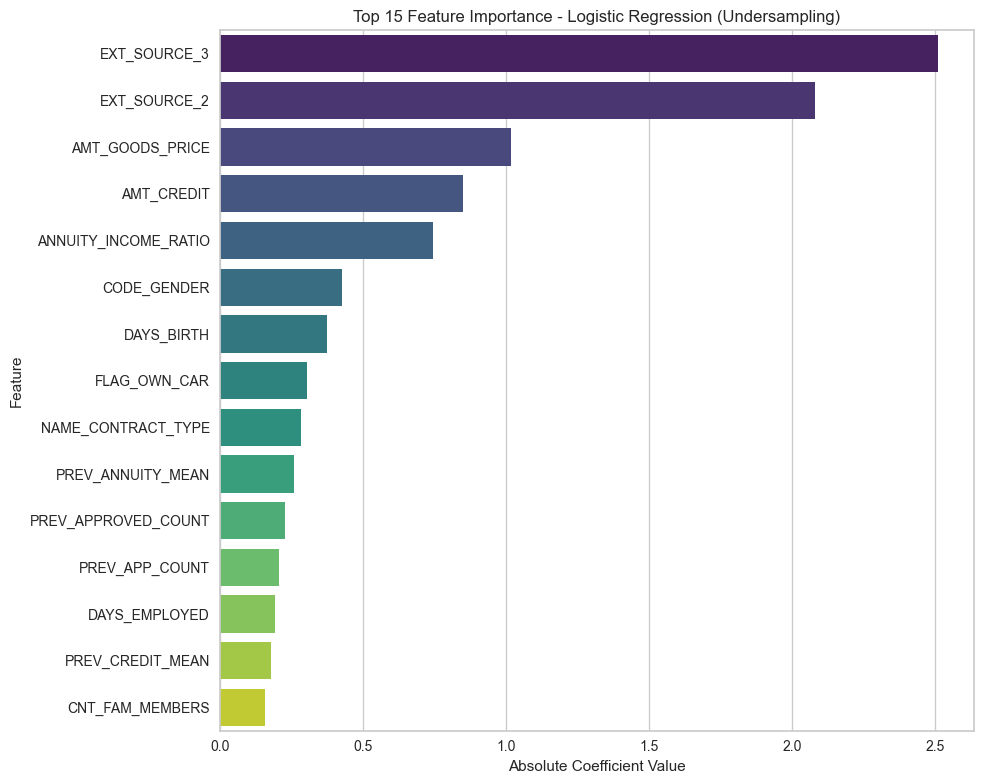


Top 10 Most Important Features:
                 Feature  Coefficient
39          EXT_SOURCE_3     2.510438
38          EXT_SOURCE_2     2.078838
8        AMT_GOODS_PRICE     1.018793
6             AMT_CREDIT     0.851046
68  ANNUITY_INCOME_RATIO     0.745147
1            CODE_GENDER     0.425883
15            DAYS_BIRTH     0.375489
2           FLAG_OWN_CAR     0.306099
0     NAME_CONTRACT_TYPE     0.283537
61     PREV_ANNUITY_MEAN     0.261529


In [45]:
# Feature Importance dari LR-Undersampling
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(lr_under.coef_[0])
}).sort_values('Coefficient', ascending=False)

# Visualisasi Top 15 Feature Importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance - Logistic Regression (Undersampling)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# **KESIMPULAN DAN REKOMENDASI**

## **Ringkasan Hasil Model**

Berdasarkan evaluasi 6 model yang telah dibuat, berikut adalah hasil perbandingan:

| Model | Accuracy | ROC-AUC | Recall Kelas 1 |
|-------|----------|---------|----------------|
| LR-Original | 91.95% | 50.60% | 1% |
| LR-SMOTE | 76.09% | 61.12% | 43% |
| **LR-Undersampling** | **68.94%** | **68.43%** | **68%** |
| RF-Original | 91.93% | 50.09% | 1% |
| RF-SMOTE | 91.55% | 50.87% | 2% |
| RF-Undersampling | 69.01% | 67.72% | 66% |

## **Analisis**

Model Original (LR & RF) memiliki accuracy tinggi (~92%) namun recall kelas 1 sangat rendah (~1%). Ini karena model cenderung memprediksi semua data sebagai kelas 0 (lancar), sehingga tidak efektif untuk mendeteksi peminjam bermasalah.

Model dengan teknik balancing (SMOTE dan Undersampling) menunjukkan performa lebih baik dalam mendeteksi kelas 1, meskipun accuracy keseluruhan turun. 

**LR-Undersampling** memiliki kombinasi terbaik dengan ROC-AUC tertinggi (68.43%) dan recall kelas 1 tertinggi (68%), yang berarti model ini paling baik dalam membedakan kedua kelas dan mendeteksi peminjam bermasalah.

## **Feature Importance - Business Insight**

Dari analisis feature importance model LR-Undersampling, fitur-fitur yang paling berpengaruh terhadap prediksi risiko kredit adalah:

**Implikasi Bisnis:**
- **EXT_SOURCE**: Skor eksternal dari lembaga kredit menjadi faktor paling penting. Bank sebaiknya fokus verifikasi skor kredit eksternal
- **DAYS_BIRTH & AGE_YEARS**: Usia peminjam berpengaruh signifikan terhadap risiko. Perlu strategi berbeda untuk segmen usia tertentu
- **DAYS_EMPLOYED & YEARS_EMPLOYED**: Stabilitas pekerjaan menjadi indikator penting. Peminjam dengan masa kerja lebih lama cenderung lebih rendah risiko
- **AMT_CREDIT & AMT_INCOME_TOTAL**: Rasio kredit terhadap income perlu diperhatikan dalam proses approval
- **Bureau Features**: Riwayat kredit di bank lain (overdue, total debt) sangat berpengaruh terhadap keputusan

**Rekomendasi untuk Bank:**
- Prioritaskan verifikasi mendalam untuk fitur-fitur dengan importance tinggi
- Gunakan threshold berbeda untuk segmen pelanggan berdasarkan profil risiko
- Pertimbangkan automated scoring system berbasis fitur-fitur penting ini

## **Rekomendasi Model**

**Model yang direkomendasikan: Logistic Regression dengan Undersampling**

Alasan:
- ROC-AUC tertinggi (68.43%) menunjukkan kemampuan diskriminasi terbaik
- Recall kelas 1 tertinggi (68%) - dapat mendeteksi 68% peminjam bermasalah
- Untuk kasus credit risk, lebih baik mendeteksi peminjam bermasalah meskipun accuracy turun

Trade-off yang diterima:
- Accuracy turun ke ~69% (dari ~92%)
- Beberapa peminjam lancar mungkin diprediksi bermasalah (false positive)
- Namun ini lebih baik daripada melewatkan peminjam bermasalah (false negative)

# **DATA TEST PREDICTION**

In [46]:
# Gunakan df_test yang sudah di-merge sebelumnya
df_test_pred = df_test.copy()

# Hapus kolom yang sama seperti saat training
df_test_pred = df_test_pred.drop(columns=cols_to_drop, errors='ignore')
df_test_pred = df_test_pred.drop(columns=cols_to_remove, errors='ignore')

# Imputasi missing values
df_test_pred[num_cols] = imputer_num.transform(df_test_pred[num_cols])
df_test_pred[cat_cols] = imputer_cat.transform(df_test_pred[cat_cols])

# Feature engineering (sama seperti training)
df_test_pred['AGE_YEARS'] = (-df_test_pred['DAYS_BIRTH'] / 365).astype(int)
df_test_pred['YEARS_EMPLOYED'] = df_test_pred['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x<0 else 0)
df_test_pred['CREDIT_INCOME_RATIO'] = df_test_pred['AMT_CREDIT'] / df_test_pred['AMT_INCOME_TOTAL']
df_test_pred['ANNUITY_INCOME_RATIO'] = df_test_pred['AMT_ANNUITY'] / df_test_pred['AMT_INCOME_TOTAL']

# Encoding kategorikal
for col in cat_cols:
    df_test_pred[col] = le.fit_transform(df_test_pred[col].astype(str))

# Pilih kolom yang sama dengan training dan scaling
X_test = df_test_pred[X.columns]
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Prediksi menggunakan model LR-Undersampling
y_pred_test = lr_under.predict(X_test)
y_pred_proba = lr_under.predict_proba(X_test)[:, 1]

print(f"Jumlah prediksi: {len(y_pred_test)}")
print(f"Prediksi Lancar (0): {(y_pred_test == 0).sum()}")
print(f"Prediksi Bermasalah (1): {(y_pred_test == 1).sum()}")

Jumlah prediksi: 48744
Prediksi Lancar (0): 31955
Prediksi Bermasalah (1): 16789


In [47]:
# Simpan hasil prediksi ke file submission
df_test_original = pd.read_csv('application_test.csv')
df_test_original['TARGET'] = y_pred_proba

print(f"Total kolom: {len(df_test_original.columns)}")
print(f"Total baris: {len(df_test_original)}")
print("\nPreview 5 baris pertama:")

Total kolom: 122
Total baris: 48744

Preview 5 baris pertama:


In [48]:
df_test_original.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.424299
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.697961
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0,0.220822
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.277628
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.542182
